In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('dataset2.csv')

In [3]:
data

,Date,Time,Latitude,Longitude,Depth,Magnitude,Magt,No stations,Gap,Dist to Closest,RMS,SRC,EventID
0,1966/07/01,09:41:21.82,35.9463,-120.4700,12.26,3.20,Mx,7,171,20,0.02,NCSN,-4540462
1,1966/07/02,12:08:34.25,35.7867,-120.3265,8.99,3.70,Mx,8,86,3,0.04,NCSN,-4540520
2,1966/07/02,12:16:14.95,35.7928,-120.3353,9.88,3.40,Mx,8,89,2,0.03,NCSN,-4540521
3,1966/07/02,12:25:06.12,35.7970,-120.3282,9.09,3.10,Mx,8,101,3,0.08,NCSN,-4540522
4,1966/07/05,18:54:54.36,35.9223,-120.4585,7.86,3.10,Mx,9,161,14,0.04,NCSN,-4540594
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18025,2007/12/19,12:14:09.62,34.1438,-116.9822,7.03,4.06,ML,10,73,14,0.08,NCSN,40207706
18026,2007/12/21,12:14:56.45,37.3078,-121.6735,8.47,3.08,ML,114,45,5,0.12,NCSN,51192926
18027,2007/12/23,21:43:43.54,37.2127,-117.8230,10.00,3.54,ML,45,176,40,0.07,NCSN,51193070
18028,2007/12/28,01:59:42.40,36.5292,-121.1133,5.99,3.04,ML,70,45,4,0.06,NCSN,51193343


In [4]:
# Convert the 'date' column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Set the 'date' column as the index
data.set_index('Date', inplace=True)

# Resample to daily frequency
daily_data = data.resample('D').agg(
    magnitude=('Magnitude', 'max'),       # Maximum value of 'magnitude' per day
    entry_count=('Magnitude', 'count'),   # Count of entries per day
    avg_magnitude=('Magnitude', 'mean')  # Average magnitude per day
)

# Display the resulting DataFrame
print(daily_data.head())

            magnitude  entry_count  avg_magnitude
Date                                             
1966-07-01        3.2            1            3.2
1966-07-02        3.7            3            3.4
1966-07-03        NaN            0            NaN
1966-07-04        NaN            0            NaN
1966-07-05        3.1            1            3.1


In [5]:
#Fill missing values with 0
daily_data = daily_data.fillna(0)

# Display the resulting DataFrame
print(daily_data.head())

            magnitude  entry_count  avg_magnitude
Date                                             
1966-07-01        3.2            1            3.2
1966-07-02        3.7            3            3.4
1966-07-03        0.0            0            0.0
1966-07-04        0.0            0            0.0
1966-07-05        3.1            1            3.1


In [6]:
target = daily_data['magnitude']

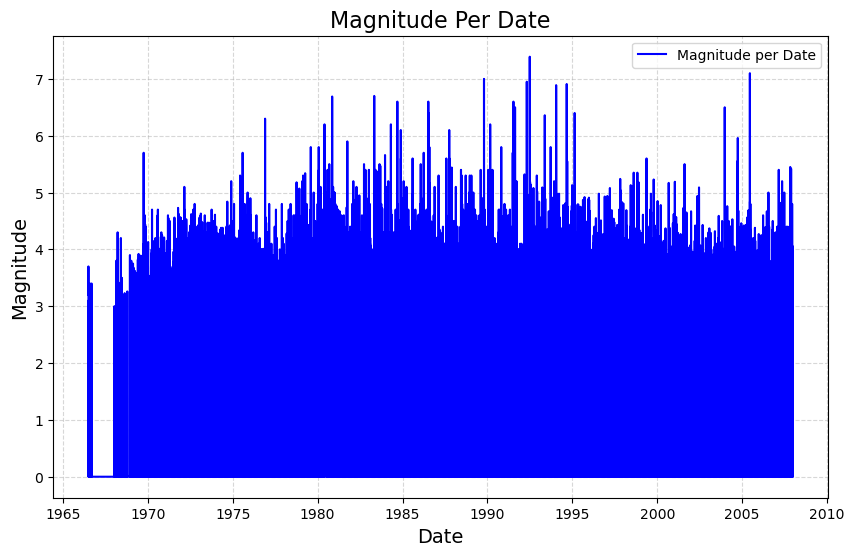

In [7]:
import matplotlib.pyplot as plt

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(daily_data.index, daily_data['magnitude'], label='Magnitude per Date', color='blue')

# Add title and labels
plt.title('Magnitude Per Date', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

In [8]:
# Resample to daily frequency
monthly_data = data.resample('ME').agg(
    magnitude=('Magnitude', 'max'),       # Maximum value of 'magnitude' per day
    entry_count=('Magnitude', 'count'),   # Count of entries per day
    avg_magnitude=('Magnitude', 'mean'),  # Average magnitude per day
)

#Fill missing values with 0
monthly_data = monthly_data.fillna(0)

# Display the resulting DataFrame
print(monthly_data.head())

            magnitude  entry_count  avg_magnitude
Date                                             
1966-07-31        3.7            6       3.250000
1966-08-31        3.4            3       3.233333
1966-09-30        3.4            1       3.400000
1966-10-31        0.0            0       0.000000
1966-11-30        0.0            0       0.000000


In [9]:
# Filter the Series to include only data after a certain date
filtered_data = monthly_data[monthly_data.index > '1970-01-01']

print(filtered_data)

            magnitude  entry_count  avg_magnitude
Date                                             
1970-01-31       4.13           20       3.310500
1970-02-28       3.54           20       3.229000
1970-03-31       4.70           26       3.432692
1970-04-30       4.13           17       3.315882
1970-05-31       4.15           35       3.346000
...               ...          ...            ...
2007-08-31       4.40           15       3.299333
2007-09-30       4.40           18       3.511667
2007-10-31       5.45           14       3.561429
2007-11-30       5.42           15       3.450667
2007-12-31       4.80           16       3.420000

[456 rows x 3 columns]


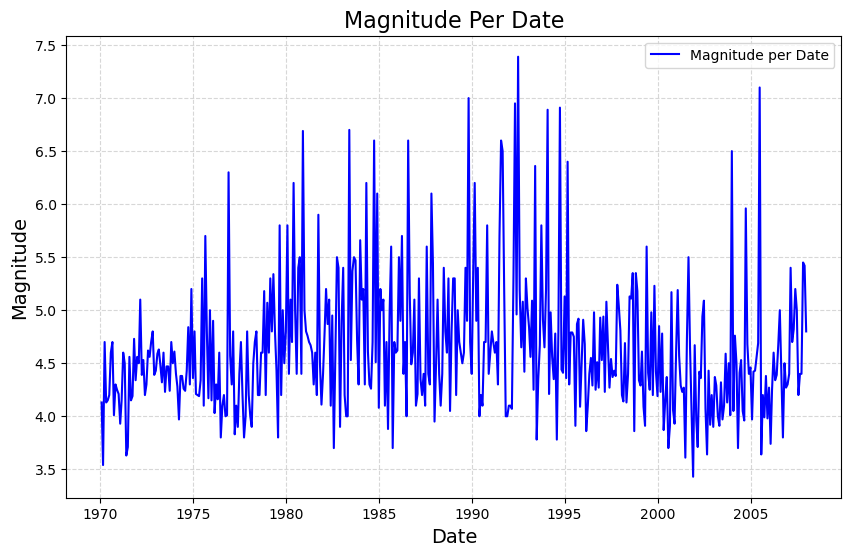

In [10]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(filtered_data.index, filtered_data['magnitude'], label='Magnitude per Date', color='blue')

# Add title and labels
plt.title('Magnitude Per Date', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

C:\Users\Piotr\AppData\Local\Temp\ipykernel_12700\3076458829.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


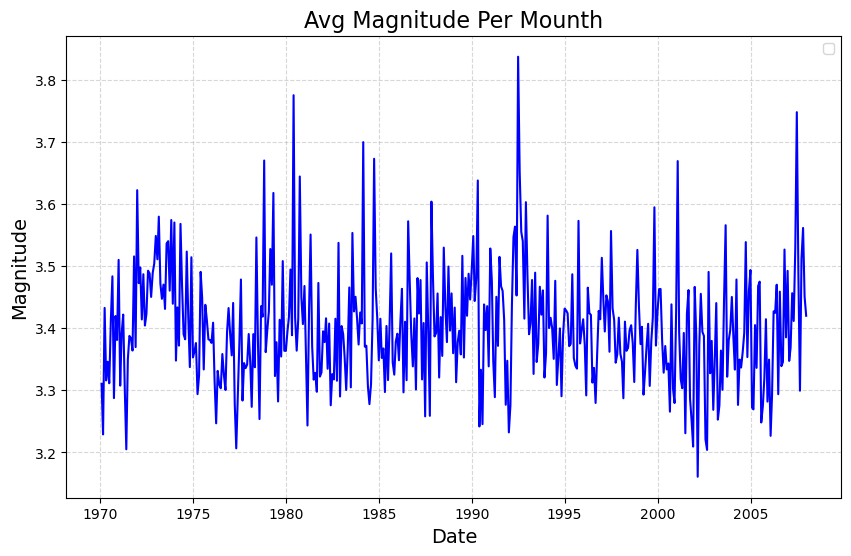

In [11]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(filtered_data.index, filtered_data['avg_magnitude'], color='blue')

# Add title and labels
plt.title('Avg Magnitude Per Mounth', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

In [12]:
filtered_data["log_avg_magnitude"] = np.log(filtered_data["avg_magnitude"])

C:\Users\Piotr\AppData\Local\Temp\ipykernel_12700\2468050327.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["log_avg_magnitude"] = np.log(filtered_data["avg_magnitude"])


In [13]:
filtered_data

,magnitude,entry_count,avg_magnitude,log_avg_magnitude
Date,,,,
1970-01-31,4.13,20,3.310500,1.197099
1970-02-28,3.54,20,3.229000,1.172172
1970-03-31,4.70,26,3.432692,1.233345
1970-04-30,4.13,17,3.315882,1.198724
1970-05-31,4.15,35,3.346000,1.207766
...,...,...,...,...
2007-08-31,4.40,15,3.299333,1.193720
2007-09-30,4.40,18,3.511667,1.256091
2007-10-31,5.45,14,3.561429,1.270162


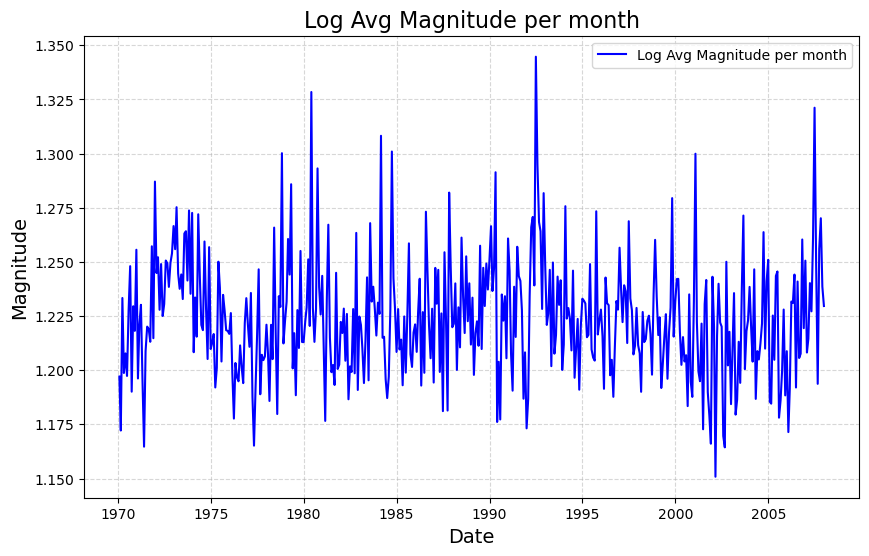

In [14]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(filtered_data.index, filtered_data['log_avg_magnitude'], label='Log Avg Magnitude per month', color='blue')

# Add title and labels
plt.title('Log Avg Magnitude per month', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

Daily Data

In [11]:

filtered_data = daily_data[daily_data.index > '1970-01-01']

print(filtered_data)

            magnitude  entry_count  avg_magnitude
Date                                             
1970-01-02       0.00            0          0.000
1970-01-03       3.70            2          3.350
1970-01-04       3.40            2          3.235
1970-01-05       3.30            1          3.300
1970-01-06       4.13            3          3.810
...               ...          ...            ...
2007-12-24       0.00            0          0.000
2007-12-25       0.00            0          0.000
2007-12-26       0.00            0          0.000
2007-12-27       0.00            0          0.000
2007-12-28       3.40            2          3.220

[13875 rows x 3 columns]


Time Series on average magnitude data for month

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [16]:
train_data = filtered_data['avg_magnitude'][:-12]  # Use all but the last year for training
test_data = filtered_data['avg_magnitude'][-12:]  # Use the last year (12 months) for testing

In [17]:
train_data.max()

3.837142857142857

In [18]:
model = SARIMAX(train_data,
                order=(1, 1, 1),  # Non-seasonal order (p, d, q)
                seasonal_order=(1, 1, 1, 72),  # Seasonal order (P, D, Q, s)
                enforce_stationarity=False,
                enforce_invertibility=False)
sarimax_model = model.fit(disp=False)

In [19]:
# Step 5: Make predictions
forecast = sarimax_model.get_forecast(steps=len(test_data))
forecast_index = test_data.index
forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

In [20]:
forecast

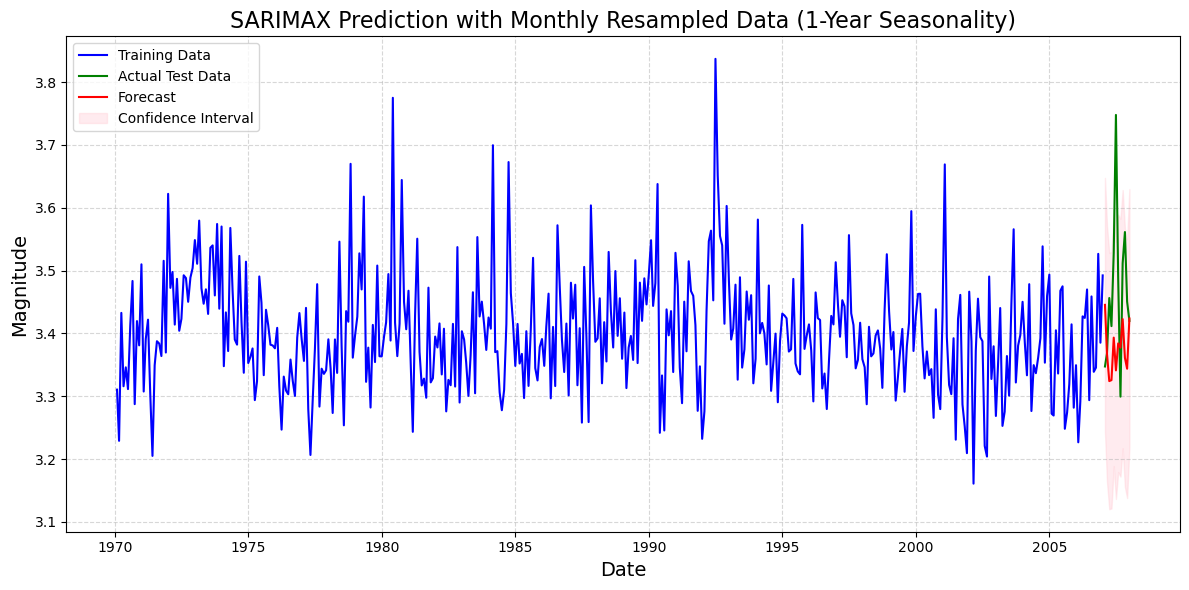

In [21]:
# Step 6: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train_data, label='Training Data', color='blue')
plt.plot(test_data, label='Actual Test Data', color='green')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_index, 
                 forecast_conf_int.iloc[:, 0], 
                 forecast_conf_int.iloc[:, 1], 
                 color='pink', alpha=0.3, label='Confidence Interval')
plt.title('SARIMAX Prediction with Monthly Resampled Data (1-Year Seasonality)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [22]:
# Evaluation metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(test_data, forecast_mean) 
mae = mean_absolute_error(test_data, forecast_mean) 
r2 = r2_score(test_data, forecast_mean) 
print(f'MSE: {mse}') 
print(f'MAE: {mae}') 
print(f'R-squared: {r2}')

MSE: 0.024524210254507756
MAE: 0.12000552886258664
R-squared: -0.9393266938955589


In [21]:
import skforecast

In [22]:
from skforecast.model_selection import grid_search_sarimax
# import skforecast
# skforecast.model_selection_s
param_grid = {
    'order': [(1, 1, 1), (0, 1, 2), (1, 1, 2)],
    'seasonal_order': [(1, 1, 1, 12), (0, 1, 1, 12), (1, 1, 0, 12)],
    'trend': [None, 'n', 'c']
}

In [24]:
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.base import BaseEstimator
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import itertools

In [ ]:
p = d = q = range(0, 2)

P = D = Q = range(0, 2)
m = [72]  # Seasonal period

pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(P, D, Q, m))


# Grid Search Function
best_aic = float("inf")
best_pdq = None
best_seasonal_pdq = None

for param in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            model = SARIMAX(train_data,
                            order=param,
                            seasonal_order=seasonal_param,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            results = model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_pdq = param
                best_seasonal_pdq = seasonal_param
        except Exception as e:
            continue

c:\Users\Piotr\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Piotr\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Piotr\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [31]:
print(f'Best SARIMAX Model: Order={best_pdq}, Seasonal Order={best_seasonal_pdq}, AIC={best_aic}')

Best SARIMAX Model: Order=(0, 1, 1), Seasonal Order=(0, 0, 0, 72), AIC=-1896.0894060889063


In [32]:
# Step 5: Make predictions
forecast = results.get_forecast(steps=len(test_data))
forecast_index = test_data.index
forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

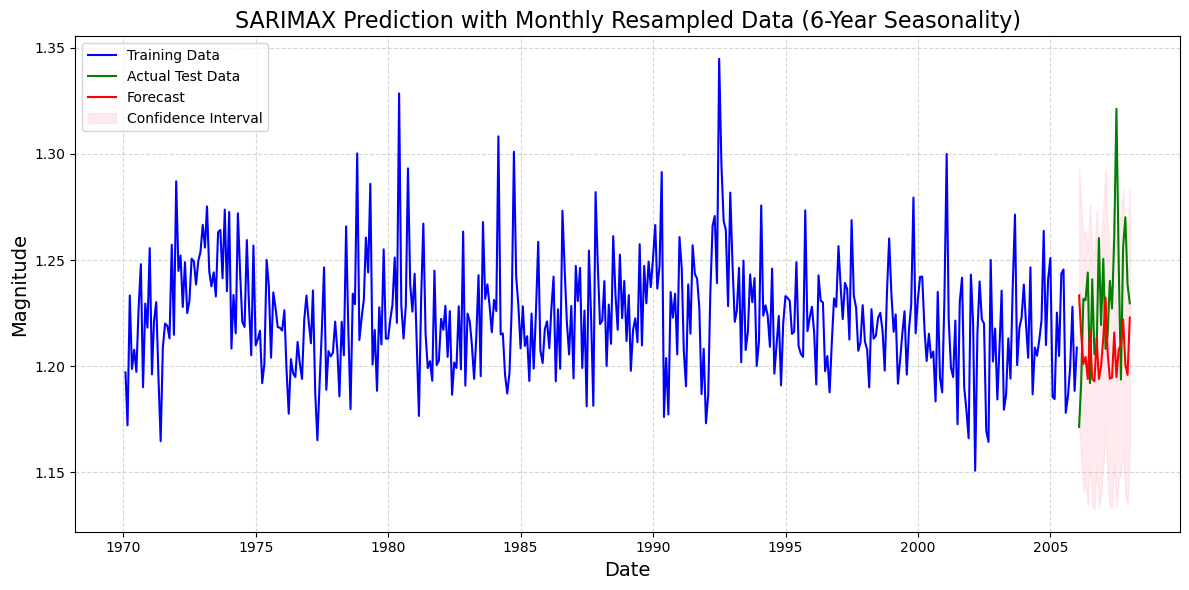

In [33]:
# Step 6: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train_data, label='Training Data', color='blue')
plt.plot(test_data, label='Actual Test Data', color='green')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_index, 
                 forecast_conf_int.iloc[:, 0], 
                 forecast_conf_int.iloc[:, 1], 
                 color='pink', alpha=0.3, label='Confidence Interval')
plt.title('SARIMAX Prediction with Monthly Resampled Data (6-Year Seasonality)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
mse = mean_squared_error(test_data, forecast_mean) 
mae = mean_absolute_error(test_data, forecast_mean) 
r2 = r2_score(test_data, forecast_mean) 
print(f'MSE: {mse}') 
print(f'MAE: {mae}') 
print(f'R-squared: {r2}')

MSE: 0.0020560559932009154
MAE: 0.037447955807962875
R-squared: -1.1162240050427314
